In [1]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import hadamard

import graph_state.graph_state as gs
from experiment_module.experiment_results_processor import load_bsqn_incremental_sampling_data
from experiment_module.incremental import bell_diagonal_incremental_scalability_experiment

# Exploring the scalability of the BSQN protocol

These experiments give us some idea as to how the upper and lower bounds of the
BSQN protocol behave.

## I. Generating data for the $\mathcal{l}_2$-norm

Here, we compute the average minimum number of samples to get $\| \Delta \mathbf{a} \|_2 \le \epsilon$.
The curves should be non-increasing with respect to $n$, showing that the upper bound does
not depend on the graph state size.

In [2]:
norm_order = 2
repeats = 100
output_dir = f"simulation_data/incremental_norm_{norm_order}"
incremental_step = 5
initial_sample_size = 1000

results = bell_diagonal_incremental_scalability_experiment(
    graphs=[gs.GraphState(i, "complete") for i in range(2, 20)],
    err_model=["depolarizing", "single-qubit-dephasing", "bimodal"],
    fidelity=[0.51, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9],
    epsilon=[0.05],
    num_repeats=repeats,
    norm_order=norm_order,
    output_dir=output_dir,
    overwrite=False,
    incremental_step=incremental_step,
    initial_sample_size=initial_sample_size,
)

Saving experiment data to: 'simulation_data/incremental_norm_2/'
Starting Bell incremental sampling experiment for 18 graph(s), 3 error model(s), 9 fidelity value(s), 1 epsilons, 100 trials, for the 2-norm of ||da||.
Total combinations (jobs) to run: 48600.
Running on 14 processes...


Running Experiments: 100%|██████████| 48600/48600 [00:07<00:00, 6205.58it/s]


## II. Retrieving the data

In [3]:
df_l2_raw = load_bsqn_incremental_sampling_data("simulation_data/incremental_norm_2")
df_l2_raw

,qubits,error_type,fidelity,epsilon,norm_order,delta_a_norm,repeat,total_samples
0,2,single-qubit-dephasing,0.55,0.05,2,0.048764,181,1100
1,15,single-qubit-dephasing,0.60,0.05,2,0.046950,60,420
2,17,single-qubit-dephasing,0.60,0.05,2,0.047245,27,510
3,7,depolarizing,0.95,0.05,2,0.042288,153,90
4,17,depolarizing,0.75,0.05,2,0.049272,151,290
...,...,...,...,...,...,...,...,...
118427,8,single-qubit-dephasing,0.60,0.05,2,0.049288,68,542
118428,7,single-qubit-dephasing,0.55,0.05,2,0.049226,180,1220
118429,8,single-qubit-dephasing,0.55,0.05,2,0.049403,183,960
118430,8,bimodal,1.00,0.05,2,NaN,93,0


In [4]:
# Filtering the data; this will be used primarily in the report
repeats = 100
error_types = ["depolarizing", "single-qubit-dephasing", "bimodal"]
fidelities = [0.51, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]

df_l2 = df_l2_raw[
    (df_l2_raw["fidelity"].isin(fidelities)) &
    (df_l2_raw["repeat"] <= repeats)
]

assert np.all(df_l2.groupby(["error_type", "fidelity", "qubits"]).transform("size") == repeats), "not enough repetitions"
df_l2

,qubits,error_type,fidelity,epsilon,norm_order,delta_a_norm,repeat,total_samples
1,15,single-qubit-dephasing,0.60,0.05,2,0.046950,60,420
2,17,single-qubit-dephasing,0.60,0.05,2,0.047245,27,510
5,4,single-qubit-dephasing,0.65,0.05,2,0.045421,25,550
6,6,single-qubit-dephasing,0.65,0.05,2,0.049814,62,520
11,8,single-qubit-dephasing,0.60,0.05,2,0.049090,71,566
...,...,...,...,...,...,...,...,...
118411,7,bimodal,0.55,0.05,2,0.039245,69,1010
118412,2,single-qubit-dephasing,0.90,0.05,2,0.045803,35,50
118424,15,single-qubit-dephasing,0.60,0.05,2,0.048855,79,540
118427,8,single-qubit-dephasing,0.60,0.05,2,0.049288,68,542


## III. Doing some post-processing

Here, we compute the average, the standard deviation, the median and the
median absolute deviation of the data. In the report, we use the median and
the median absolute deviation since they are robust to outliers.

_Note: using the interquartile range was also considered, but it also resulted
in a messy plot; the median and the MAD allows for a better visualization of
what is actually going on in the algorithm._

In [5]:
err_models = {
    "depolarizing": "dep",
    "single-qubit-dephasing": "sqd",
    "bimodal": "bim"
}

medians_df = pd.DataFrame(index=range(2, 20))

for e, c in err_models.items():
    for f in fidelities:
        samples = df_l2[
            (df_l2["error_type"] == e) & (df_l2["fidelity"] == f)
        ].copy()

        samples_per_qubit = samples.groupby("qubits")["total_samples"]

        results_df = pd.DataFrame(
            {
                f"{c}-{f}-avg": samples_per_qubit.mean(),
                f"{c}-{f}-std": samples_per_qubit.std(),
                f"{c}-{f}-medians": samples_per_qubit.median(),
                f"{c}-{f}-mads": samples["total_samples"].sub(
                    samples_per_qubit.transform("median")
                ).abs().groupby(samples["qubits"]).median(),
            },
            index=range(2, 20),
        )
        medians_df = pd.concat([medians_df, results_df], axis=1)

medians_df.index.name = "qubits"
medians_df

,dep-0.51-avg,dep-0.51-std,dep-0.51-medians,dep-0.51-mads,dep-0.55-avg,dep-0.55-std,dep-0.55-medians,dep-0.55-mads,dep-0.6-avg,dep-0.6-std,...,bim-0.8-medians,bim-0.8-mads,bim-0.85-avg,bim-0.85-std,bim-0.85-medians,bim-0.85-mads,bim-0.9-avg,bim-0.9-std,bim-0.9-medians,bim-0.9-mads
qubits,,,,,,,,,,,,,,,,,,,,,
2,1649.6,1235.060969,1125.0,265.0,1331.2,903.715429,1060.0,280.0,1062.70,662.447032,...,285.0,155.0,299.6,243.285259,220.0,100.0,145.40,107.312627,120.0,60.0
3,1222.3,524.818112,1085.0,220.0,1090.6,480.214220,1010.0,190.0,841.50,329.518703,...,430.0,250.0,304.3,224.347561,240.0,135.0,187.30,155.211521,140.0,80.0
4,1191.5,418.038650,1100.0,230.0,1043.0,346.539895,1005.0,175.0,865.70,273.304710,...,340.0,180.0,286.2,225.405493,205.0,115.0,163.10,142.472361,110.0,50.0
5,1174.4,300.871864,1140.0,195.0,994.5,259.254467,1000.0,180.0,822.10,257.530208,...,250.0,115.0,312.7,286.345327,200.0,100.0,184.20,163.300430,135.0,75.0
6,1117.9,252.923492,1060.0,110.0,967.5,233.525354,930.0,120.0,785.10,226.691153,...,287.0,139.0,278.5,207.828479,220.0,100.0,163.46,138.662836,123.0,63.0
7,1075.8,186.369786,1020.0,75.0,944.1,206.647580,930.0,100.0,782.00,190.079834,...,320.0,157.0,304.1,255.010774,230.0,130.0,163.48,122.134094,126.0,72.0
8,1063.7,204.433956,1020.0,90.0,909.4,189.143845,885.0,105.0,759.60,159.994697,...,347.0,196.0,285.9,211.154092,240.0,120.0,155.66,115.456076,112.0,57.0
9,1083.5,186.213601,1020.0,70.0,922.1,155.220892,885.0,85.0,760.74,179.434950,...,309.0,136.0,245.2,189.771154,190.0,95.0,165.36,166.995525,112.0,55.0
10,1124.8,219.675978,1050.0,90.0,940.6,179.369378,875.0,75.0,758.38,182.236320,...,304.0,148.0,292.5,205.241297,245.0,95.0,188.74,141.973864,144.0,74.0


In [6]:
medians_df.to_csv("simulation_data/processed_csv/incremental.csv", sep="\t")

## IV. Plotting the results

This plot is more of a draft. The plots in the final report will be done using native
$\LaTeX$ tools and a CSV file with the results.

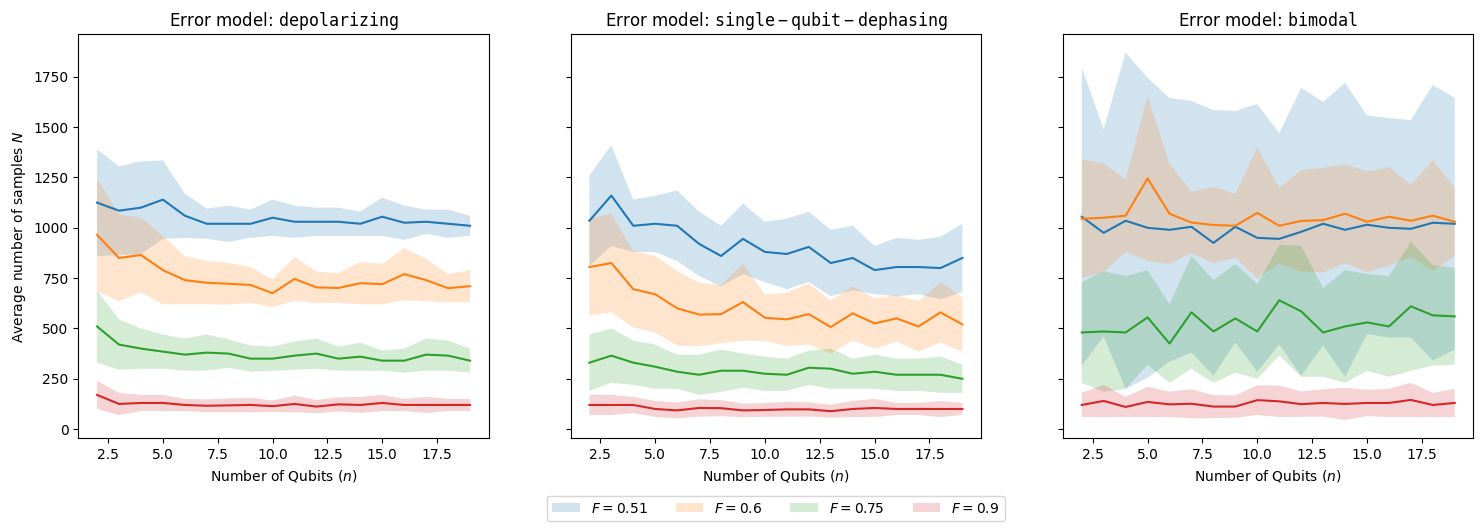

In [7]:
fidelities = [0.51, 0.60, 0.75, 0.9]

fig, axes = plt.subplots(
    1,
    len(err_models),
    figsize=(6 * len(err_models), 8),
    sharey=True,
    # sharex=True,
)

for j, err_model_mapping in enumerate(err_models.items()):
    err_model_name, err_model_alias = err_model_mapping

    for f in fidelities:
        axes[j].fill_between(
            medians_df.index,
            medians_df[f"{err_model_alias}-{f}-medians"] - medians_df[f"{err_model_alias}-{f}-mads"],
            medians_df[f"{err_model_alias}-{f}-medians"] + medians_df[f"{err_model_alias}-{f}-mads"],
            alpha=0.2,
            label=f"$F = {f}$",
        )
        axes[j].plot(medians_df.index, medians_df[f"{err_model_alias}-{f}-medians"])

        axes[j].set_title(rf"Error model: $\mathtt{{{err_model_name}}}$")
        axes[j].set_xlabel("Number of Qubits ($n$)")

        if j == 0:
            axes[j].set_ylabel(r"Average number of samples $N$")

        box = axes[j].get_position()
        axes[j].set_position(
            [box.x0, box.y0 + box.height * 0.1, box.width, box.height * 0.9]
        )

axes[1].legend(
    loc='upper center', bbox_to_anchor=(0.5, -0.125),
    fancybox=True, ncol=len(fidelities)
)

plt.show()

## Interlude. Analyzing the $P$ matrix

While developing the proof for the $n$-independent upper bound, I ended up investigating
many properties of the $P$ matrix that transforms the Bell sampling measurements $\mathbf{m}$
into the averages for each stabilizer $\mathbf{c}$. The main result can be found in
Proposition 1 of the report: $P \in \{-1, 1\}^{2^{n} \times 2^{2n}}$ is an unnormalized
partial Hadamard matrix where its rows sum up to a row vector where each element is either
$0$ or $2^n$.

In [8]:
def get_stabilizers(g: gs.GraphState) -> list[str]:
    """List all stabilizers (as strings) for a given graph state."""
    return ["I" * g.n] + [
        "".join("XZYI"[s.tolist()[i::g.n].index(True) if any(s.tolist()[i::g.n]) else -1] for i in range(g.n))
        for s in g.generate_all_int_stabilizers()
    ]


def get_phm_indices(g: gs.GraphState) -> list[int]:
    """Get the row indices for the P matrix of a given state."""
    stabilizers = get_stabilizers(g)
    base_operators = ["II", "XX", "ZZ", "YY"]
    candidates = ["".join(e) for e in product(base_operators, repeat=g.n)]
    operators = ["".join(2 * c for c in s) for s in stabilizers]
    return sorted([candidates.index(o) for o in operators])


def check_row_sum(g: gs.GraphState) -> None:
    """Test if the rows of a given state's P matrix sum up to 0 or 2^n."""
    indices = get_phm_indices(g)
    row_sum = hadamard(2 ** (2 * g.n))[indices, :].sum(axis=0)
    print(row_sum)
    return all(x in (0.0, float(2 ** g.n)) for x in row_sum)

In [9]:
check_row_sum(gs.GraphState(4, graph_type="random-tree"))

[16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 16  0  0  0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0
  0  0 16  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0 16
  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0 16  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 16  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0 16  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 16  0
  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0]


True

Another very useful experiment is to see how the norm of error vectors behave
when multiplied by $P$. In this case, we want to check that if $\|\Delta\mathbf{m}\|_2 = \epsilon$,
then $\| P \Delta \mathbf{m} \|_2 \le \sqrt{2^n} \epsilon$. This is the relation used to prove
the $n$-independent upper bound.

In [10]:
def create_delta_m(n: int, N: int = 1000) -> np.ndarray:
    """Create dm from a distribution and an estimation of it."""
    rng = np.random.default_rng()
    dist_original = rng.random((2 ** n) ** 2)
    dist_original = dist_original / np.linalg.norm(dist_original, ord=1)

    samples = np.random.choice((2 ** n) ** 2, N, p=dist_original).tolist()
    dist_estimation = np.array([samples.count(i) for i in np.arange((2 ** n) ** 2)]) / N
    return dist_original - dist_estimation

In [11]:
n_trials = 200

for n in range(3, 8):
    # Get the partial Hadamard matrix...
    g = gs.GraphState(n, graph_type="complete")
    indices = get_phm_indices(g)
    h = hadamard(2 ** (2 * n))[indices, :]

    # And generate a bunch of dms and check the average distortion
    average = 0
    for _ in range(n_trials):
        estimation = create_delta_m(n)
        average += np.linalg.norm(h.dot(estimation), ord=2) / np.linalg.norm(estimation, ord=2)

    # Ideally, for large enough n_trials, distortion <= sqrt(2 ** n)
    print(f"n = {n}, nrows = {2 ** n}, sqrt(nrows) = {np.sqrt(2 ** n)}, distortion: {average / n_trials}")

n = 3, nrows = 8, sqrt(nrows) = 2.8284271247461903, distortion: 2.5235085633375847
n = 4, nrows = 16, sqrt(nrows) = 4.0, distortion: 3.7951985204502527
n = 5, nrows = 32, sqrt(nrows) = 5.656854249492381, distortion: 5.565832281525212
n = 6, nrows = 64, sqrt(nrows) = 8.0, distortion: 7.928852129720577
n = 7, nrows = 128, sqrt(nrows) = 11.313708498984761, distortion: 11.251207325541166


Finally, this is a useful set of functions that compute all of the
stabilizers of a given generator set. This is useful for exploration purposes.

In [12]:
def create_int_generators(generators_strs: list[str]) -> np.ndarray:
    mapping = {"I": 0, "Z": 1, "X": 2, "Y": 3}
    return np.array([
        np.array([mapping[p] for p in g])
        for g in generators_strs
    ])

In [13]:
def generate_all_int_stabilizers(generators: np.ndarray):
    n = len(generators[0])
    powers_of_2_for_selection = 2 ** np.arange(n)

    for i in range(1, 1 << n):
        selection_mask = (i & powers_of_2_for_selection) != 0
        selected_generators = generators[selection_mask]
        pauli_product_vector = np.bitwise_xor.reduce(selected_generators, axis=0)
        yield pauli_product_vector

In [14]:
def compute_stabilizers(generators: list[str]):
    mapping = {"I": 0, "Z": 1, "X": 2, "Y": 3}
    encoding = ["I", "Z", "X", "Y"]
    generators_int = np.array([np.array([mapping[p] for p in g]) for g in generators])
    return ["I" * len(generators[0])] + [
        "".join(encoding[i] for i in g)
        for g in generate_all_int_stabilizers(generators_int)
    ]

In [15]:
compute_stabilizers(["XZZ", "ZXZ", "ZZX"])

['III', 'XZZ', 'ZXZ', 'YYI', 'ZZX', 'YIY', 'IYY', 'XXX']